## WIL PROJECT
### Program Name: Artificial Intelligence & Machine Learning
### Project Code: CPL-5559-AIMT


- Aarjeyan Shrestha (C0927422)
- Karun Kumar Atreya (C0917245)
- Sudip Chaudhary (C0922310)
- Saugat Babu Bhattarai (C0916109)

**Collect, manipulate, and mine data sets to meet organizational needs.**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%matplotlib inline

In [3]:
housing_df = pd.read_csv("housing_synthetic_enhanced.csv")

In [4]:
housing_df.head()

,housing_id,housing_type,capacity,occupancy_status,location_region,availability_date,accessibility_features,proximity_to_services_km,rental_cost_eur_per_month,sponsorship_status,funding_source,accommodation_program,partner_organization,cultural_facilities,integration_services,security_level,transportation_access,community_size
0,1,Permanent Shelter,6,Vacant,Berlin,2022-08-25 00:00:00,NaN,4.57,372.13,Not Sponsored,Private Sponsor,Long-term,Pro Asyl,Halal Kitchen,NaN,Standard,True,1842
1,2,Permanent Shelter,2,Occupied,Saxony,2017-02-26 00:00:00,NaN,13.24,743.77,Not Sponsored,Government,Emergency,Diakonie,Prayer Room,Language Classes,Enhanced,False,1792
2,3,Permanent Apartment,3,Vacant,Berlin,2013-08-08 00:00:00,Wheelchair Ramp,10.22,1377.64,Not Sponsored,Private Sponsor,Long-term,Haus Willkommen,Halal Kitchen,Language Classes,Standard,False,1842
3,4,Temporary Shelter,2,Occupied,Hesse,2011-09-09 00:00:00,NaN,8.63,588.45,Sponsored,NGO,Temporary,Diakonie,NaN,NaN,Standard,False,1887
4,5,Permanent Shelter,3,Occupied,Berlin,2017-12-06 00:00:00,NaN,11.84,423.99,Not Sponsored,NGO,Emergency,Diakonie,NaN,NaN,Enhanced,False,1842


In [5]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2040 entries, 0 to 2039
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   housing_id                 2040 non-null   int64  
 1   housing_type               2040 non-null   object 
 2   capacity                   2040 non-null   int64  
 3   occupancy_status           2040 non-null   object 
 4   location_region            1834 non-null   object 
 5   availability_date          2040 non-null   object 
 6   accessibility_features     808 non-null    object 
 7   proximity_to_services_km   2040 non-null   float64
 8   rental_cost_eur_per_month  1940 non-null   float64
 9   sponsorship_status         2040 non-null   object 
 10  funding_source             2040 non-null   object 
 11  accommodation_program      2040 non-null   object 
 12  partner_organization       2040 non-null   object 
 13  cultural_facilities        1048 non-null   objec

In [6]:
refugee_df = pd.read_csv("refugees_synthetic_enhanced.csv")

In [7]:
refugee_df.head()

,date_of_arrival,country_of_origin,age,gender,family_size,language_spoken,special_needs,education_level,employment_background,preferred_region,legal_status,case_worker_id,intake_interview_date,medical_conditions,trauma_indicators,cultural_requirements,previous_residence_type
0,2012-01-13 00:00:00,Ukraine,0,Female,2,English,NaN,NaN,Retired,Berlin,Refugee,CW024,2012-02-04,NaN,NaN,Halal,Rural
1,2023-04-26 00:00:00,Syria,3,Male,5,Kurdish,NaN,Tertiary,Skilled Worker,NaN,Refugee,CW084,2023-05-02,NaN,NaN,NaN,Rural
2,2023-12-27 00:00:00,Syria,10,Female,3,Ukrainian,NaN,Secondary,Professional,NaN,Refugee,CW095,2024-01-26,NaN,NaN,NaN,Urban
3,2016-09-06 00:00:00,Somalia,58,Female,2,Arabic,NaN,Secondary,Unemployed,Bavaria,Asylum seeker,CW088,2016-09-11,NaN,Moderate,NaN,Unknown
4,2015-10-28 00:00:00,Iraq,2,Male,2,Dari,Medical Condition,NaN,Student,North Rhine-Westphalia,Asylum seeker,CW028,2015-11-24,NaN,NaN,Vegetarian,Unknown


In [8]:
refugee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   date_of_arrival          10100 non-null  object
 1   country_of_origin        10100 non-null  object
 2   age                      10100 non-null  int64 
 3   gender                   10100 non-null  object
 4   family_size              10100 non-null  int64 
 5   language_spoken          10100 non-null  object
 6   special_needs            2030 non-null   object
 7   education_level          7890 non-null   object
 8   employment_background    10100 non-null  object
 9   preferred_region         9098 non-null   object
 10  legal_status             10100 non-null  object
 11  case_worker_id           10100 non-null  object
 12  intake_interview_date    9899 non-null   object
 13  medical_conditions       5000 non-null   object
 14  trauma_indicators        3160 non-null

### Missing Value Analysis - Housing Dataset

In [9]:
missing_counts = housing_df.isnull().sum()
missing_percentage = (missing_counts / len(housing_df)) * 100

In [10]:
missing_percentage

housing_id                    0.000000
housing_type                  0.000000
capacity                      0.000000
occupancy_status              0.000000
location_region              10.098039
availability_date             0.000000
accessibility_features       60.392157
proximity_to_services_km      0.000000
rental_cost_eur_per_month     4.901961
sponsorship_status            0.000000
funding_source                0.000000
accommodation_program         0.000000
partner_organization          0.000000
cultural_facilities          48.627451
integration_services         21.372549
security_level                0.000000
transportation_access         0.000000
community_size                0.000000
dtype: float64

<Axes: >

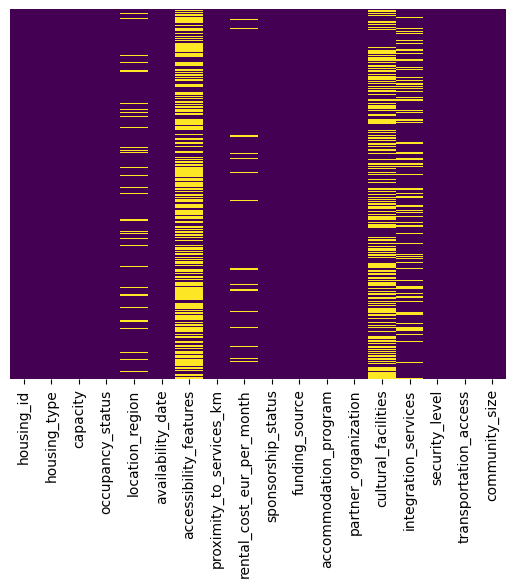

In [11]:
sns.heatmap(housing_df.isnull(),yticklabels=False,cbar=False,cmap="viridis")

In [12]:
categorical_imputation = {
    'accessibility_features': 'None',  
    'cultural_facilities': 'None',     
    'integration_services': 'None'     
}
numerical_imputation = {
    'proximity_to_services_km': 'median',  
    'rental_cost_eur_per_month': 'mean'    
}

In [13]:
# Apply imputation strategies
for column, strategy in categorical_imputation.items():
    housing_df[column].fillna(strategy, inplace=True)

for column, strategy in numerical_imputation.items():
    if strategy == 'median':
        housing_df[column].fillna(housing_df[column].median(), inplace=True)
    elif strategy == 'mean':
        housing_df[column].fillna(housing_df[column].mean(), inplace=True)

C:\Users\sthaa\AppData\Local\Temp\ipykernel_19628\3619612380.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing_df[column].fillna(strategy, inplace=True)
C:\Users\sthaa\AppData\Local\Temp\ipykernel_19628\3619612380.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

In [14]:
housing_df["accessibility_features"].value_counts()

accessibility_features
None               1232
Wheelchair Ramp     502
Elevator            306
Name: count, dtype: int64

<Axes: >

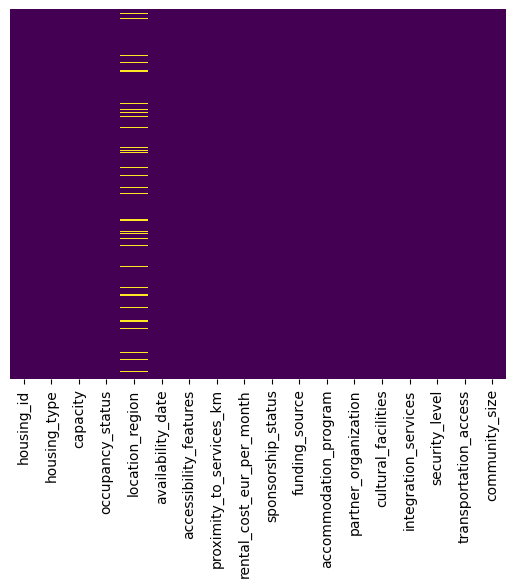

In [15]:
# after handling the missing values 
sns.heatmap(housing_df.isnull(),yticklabels=False,cbar=False,cmap="viridis")

### Refugee Dataset- Missing Value Analysis

In [16]:
refugee_missing = refugee_df.isnull().sum()
refugee_missing_pct = (refugee_missing / len(refugee_df)) * 100

<Axes: >

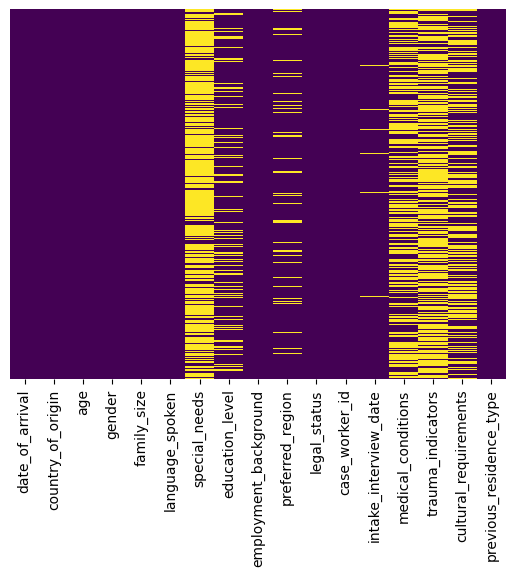

In [17]:
sns.heatmap(refugee_df.isnull(),yticklabels=False,cbar=False,cmap="viridis")

In [18]:
refugee_categorical_imputation = {
    'education_level': 'Unknown',          
    'preferred_region': 'No Preference',   
    'medical_conditions': 'None',          
    'cultural_requirements': 'None'        
}

In [19]:
# Handle special cases
# For missing employment background, using age-appropriate defaults
def impute_employment_by_age(row):
    if pd.isna(row['employment_background']):
        if row['age'] < 16:
            return 'Student'
        elif row['age'] >= 65:
            return 'Retired'
        else:
            return 'Unknown'
    return row['employment_background']

refugee_df['employment_background'] = refugee_df.apply(impute_employment_by_age, axis=1)

In [20]:
# Apply categorical imputations
for column, strategy in refugee_categorical_imputation.items():
    refugee_df[column].fillna(strategy, inplace=True)

C:\Users\sthaa\AppData\Local\Temp\ipykernel_19628\1387159538.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  refugee_df[column].fillna(strategy, inplace=True)


In [21]:
refugee_df["employment_background"].unique()

array(['Retired', 'Skilled Worker', 'Professional', 'Unemployed',
       'Student', 'Unknown'], dtype=object)

<Axes: >

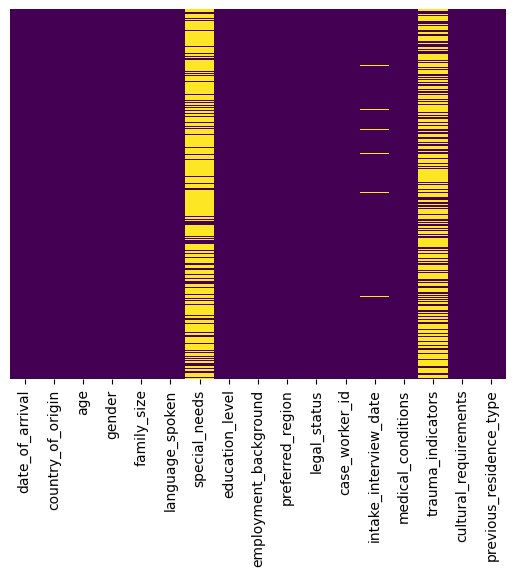

In [22]:
sns.heatmap(refugee_df.isnull(),yticklabels=False,cbar=False,cmap="viridis")

In [23]:
refugee_df["cultural_requirements"].value_counts()

cultural_requirements
None          3990
Halal         2974
Vegetarian    2079
Kosher        1057
Name: count, dtype: int64

### Housing Dataset - Data Type Correction

In [24]:
housing_df['transportation_access'] = housing_df['transportation_access'].map({
    'True': True, 
    'False': False, 
    True: True, 
    False: False
})

In [25]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2040 entries, 0 to 2039
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   housing_id                 2040 non-null   int64  
 1   housing_type               2040 non-null   object 
 2   capacity                   2040 non-null   int64  
 3   occupancy_status           2040 non-null   object 
 4   location_region            1834 non-null   object 
 5   availability_date          2040 non-null   object 
 6   accessibility_features     2040 non-null   object 
 7   proximity_to_services_km   2040 non-null   float64
 8   rental_cost_eur_per_month  2040 non-null   float64
 9   sponsorship_status         2040 non-null   object 
 10  funding_source             2040 non-null   object 
 11  accommodation_program      2040 non-null   object 
 12  partner_organization       2040 non-null   object 
 13  cultural_facilities        2040 non-null   objec

In [26]:
# datetime conversion
housing_df['availability_date'] = pd.to_datetime(housing_df['availability_date'], errors='coerce')

In [27]:

numerical_columns = ['capacity', 'proximity_to_services_km', 'rental_cost_eur_per_month', 'community_size']
for col in numerical_columns:
    housing_df[col] = pd.to_numeric(housing_df[col], errors='coerce')


categorical_columns = ['housing_type', 'occupancy_status', 'location_region', 
                      'funding_source', 'accommodation_program', 'security_level']
for col in categorical_columns:
    housing_df[col] = housing_df[col].astype('category')

In [28]:
housing_df.info() # after the changes in datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2040 entries, 0 to 2039
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   housing_id                 2040 non-null   int64         
 1   housing_type               2040 non-null   category      
 2   capacity                   2040 non-null   int64         
 3   occupancy_status           2040 non-null   category      
 4   location_region            1834 non-null   category      
 5   availability_date          1999 non-null   datetime64[ns]
 6   accessibility_features     2040 non-null   object        
 7   proximity_to_services_km   2040 non-null   float64       
 8   rental_cost_eur_per_month  2040 non-null   float64       
 9   sponsorship_status         2040 non-null   object        
 10  funding_source             2040 non-null   category      
 11  accommodation_program      2040 non-null   category      
 12  partne

### Refugee Dataset - Data Type COrrection

In [29]:
refugee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   date_of_arrival          10100 non-null  object
 1   country_of_origin        10100 non-null  object
 2   age                      10100 non-null  int64 
 3   gender                   10100 non-null  object
 4   family_size              10100 non-null  int64 
 5   language_spoken          10100 non-null  object
 6   special_needs            2030 non-null   object
 7   education_level          10100 non-null  object
 8   employment_background    10100 non-null  object
 9   preferred_region         10100 non-null  object
 10  legal_status             10100 non-null  object
 11  case_worker_id           10100 non-null  object
 12  intake_interview_date    9899 non-null   object
 13  medical_conditions       10100 non-null  object
 14  trauma_indicators        3160 non-null

In [30]:
# Datetime conversion
refugee_df['date_of_arrival'] = pd.to_datetime(refugee_df['date_of_arrival'], errors='coerce')
refugee_df['intake_interview_date'] = pd.to_datetime(refugee_df['intake_interview_date'], errors='coerce')

# required numerical and categorical conversions
numerical_refugee_cols = ['age', 'family_size']
for col in numerical_refugee_cols:
    refugee_df[col] = pd.to_numeric(refugee_df[col], errors='coerce')


categorical_refugee_cols = ['country_of_origin', 'gender', 'language_spoken', 
                           'legal_status', 'trauma_indicators', 'education_level']
for col in categorical_refugee_cols:
    refugee_df[col] = refugee_df[col].astype('category')

In [31]:
refugee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date_of_arrival          9899 non-null   datetime64[ns]
 1   country_of_origin        10100 non-null  category      
 2   age                      10100 non-null  int64         
 3   gender                   10100 non-null  category      
 4   family_size              10100 non-null  int64         
 5   language_spoken          10100 non-null  category      
 6   special_needs            2030 non-null   object        
 7   education_level          10100 non-null  category      
 8   employment_background    10100 non-null  object        
 9   preferred_region         10100 non-null  object        
 10  legal_status             10100 non-null  category      
 11  case_worker_id           10100 non-null  object        
 12  intake_interview_date    9899 no

### Logical Inconsistency Detection and Correction

#### - Housing Dataset

In [32]:
# Capacity validation
def validate_housing_capacity(row):
    if row['housing_type'] in ['Temporary Shelter', 'Emergency'] and row['capacity'] > 20:
        return 15  # Cap emergency housing at reasonable limit
    elif row['housing_type'] in ['Permanent Apartment'] and row['capacity'] > 8:
        return 6   # Cap apartment capacity
    return row['capacity']

housing_df['capacity'] = housing_df.apply(validate_housing_capacity, axis=1)


We changed the dataset according to the Real World Logic:
- Emergency shelters: Usually shared spaces, 10-20 people max
- Apartments: Individual family units, 2-8 people typically
- Large facilities would be classified as "shelters" not "apartments"

In [33]:
# Availability date logic
current_date = pd.Timestamp.now()
occupied_future_available = housing_df[
    (housing_df['occupancy_status'] == 'Occupied') & 
    (housing_df['availability_date'] > current_date)
]
# Set past availability for currently occupied housing
housing_df.loc[occupied_future_available.index, 'availability_date'] = current_date - pd.Timedelta(days=30)


In [34]:
#Proximity validation # Remove negative values
housing_df['proximity_to_services_km'] = housing_df['proximity_to_services_km'].abs()  

#### - Refugee Dataset

Some real life logic that we use for the changes:

For Age employment validataion
- Under 16: Should be students or have no employment
- Over 65: Likely retired (though some might still work)
- Working age (16-65): Any employment background is reasonable

For Date Sequence Validation
- You can't interview someone before they arrive as, this breaks the logical sequence of refugee processing
- so we changed it to 7 days of arrival for convinience


For family size validation
- Some unaccompanied minors do exist (tragic but real)
- But many cases might be data errors
- NGOs track this carefully due to special protection needs


In [35]:
# Age-employment validation
def correct_age_employment_mismatch(row):
    if row['age'] < 16 and row['employment_background'] not in ['Student', 'None', 'Unknown']:
        return 'Student'
    elif row['age'] >= 65 and row['employment_background'] not in ['Retired', 'None', 'Unknown']:
        return 'Retired'
    return row['employment_background']

refugee_df['employment_background'] = refugee_df.apply(correct_age_employment_mismatch, axis=1)

In [36]:
#Date sequence validation
date_issues = refugee_df[refugee_df['intake_interview_date'] < refugee_df['date_of_arrival']]
for idx in date_issues.index:
    # Set interview date to 7 days after arrival
    refugee_df.loc[idx, 'intake_interview_date'] = refugee_df.loc[idx, 'date_of_arrival'] + pd.Timedelta(days=7)

In [37]:
# Family size validation for minors
minor_alone = refugee_df[(refugee_df['age'] < 18) & (refugee_df['family_size'] == 1)]
# Assume unaccompanied minors have family_size = 1 but add flag
refugee_df['unaccompanied_minor'] = ((refugee_df['age'] < 18) & (refugee_df['family_size'] == 1))

### Outlier Detection and Treatment

Housing Dataset


In [38]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]


capacity_outliers = detect_outliers_iqr(housing_df, 'capacity')

housing_df.loc[housing_df['capacity'] > 25, 'capacity'] = 25


cost_outliers = detect_outliers_iqr(housing_df, 'rental_cost_eur_per_month')

max_costs = {
    'Emergency': 500,
    'Temporary Shelter': 600,
    'Temporary Apartment': 1000,
    'Permanent Shelter': 800,
    'Permanent Apartment': 1500
}

for housing_type, max_cost in max_costs.items():
    mask = housing_df['housing_type'] == housing_type
    housing_df.loc[mask & (housing_df['rental_cost_eur_per_month'] > max_cost), 
                   'rental_cost_eur_per_month'] = max_cost

- Here, for the housing dataset, we cap the capacity of people at 25 maximum as it is realistic limit for any hoousing unit.
- Also we did the caps on the specific rental cost:
    - Emergency (€500): Basic, temporary, shared facilities
    - Permanent Apartment (€1500): Individual family housing, higher quality
    - Business logic: **Prevents €3000/month "luxury" refugee housing**

Refugee Dataset

In [39]:
# age
age_outliers = refugee_df[(refugee_df['age'] < 0) | (refugee_df['age'] > 100)]

refugee_df.loc[refugee_df['age'] < 0, 'age'] = 0  
refugee_df.loc[refugee_df['age'] > 100, 'age'] = refugee_df['age'].median()  

# family size
family_size_outliers = detect_outliers_iqr(refugee_df, 'family_size')

refugee_df.loc[refugee_df['family_size'] > 12, 'family_size'] = 12

# changes in dates
future_arrivals = refugee_df[refugee_df['date_of_arrival'] > pd.Timestamp.now()]
refugee_df.loc[future_arrivals.index, 'date_of_arrival'] = pd.Timestamp.now() - pd.Timedelta(days=30)

Here for the refugee data 
- we changed all the negative ages to 0 (newborn), ages > 100 to the median age
- Apply practical cap at 12 people per family as Most families: 2-6 people, Large families: 7-10 people, Extremely large: 11-12 people,Above 12: Likely data errors or multiple families combined
- Future arrival dates: People can't arrive in the future ......Solution: Set to 30 days ago (realistic recent arrival)

### Univariate Analysis

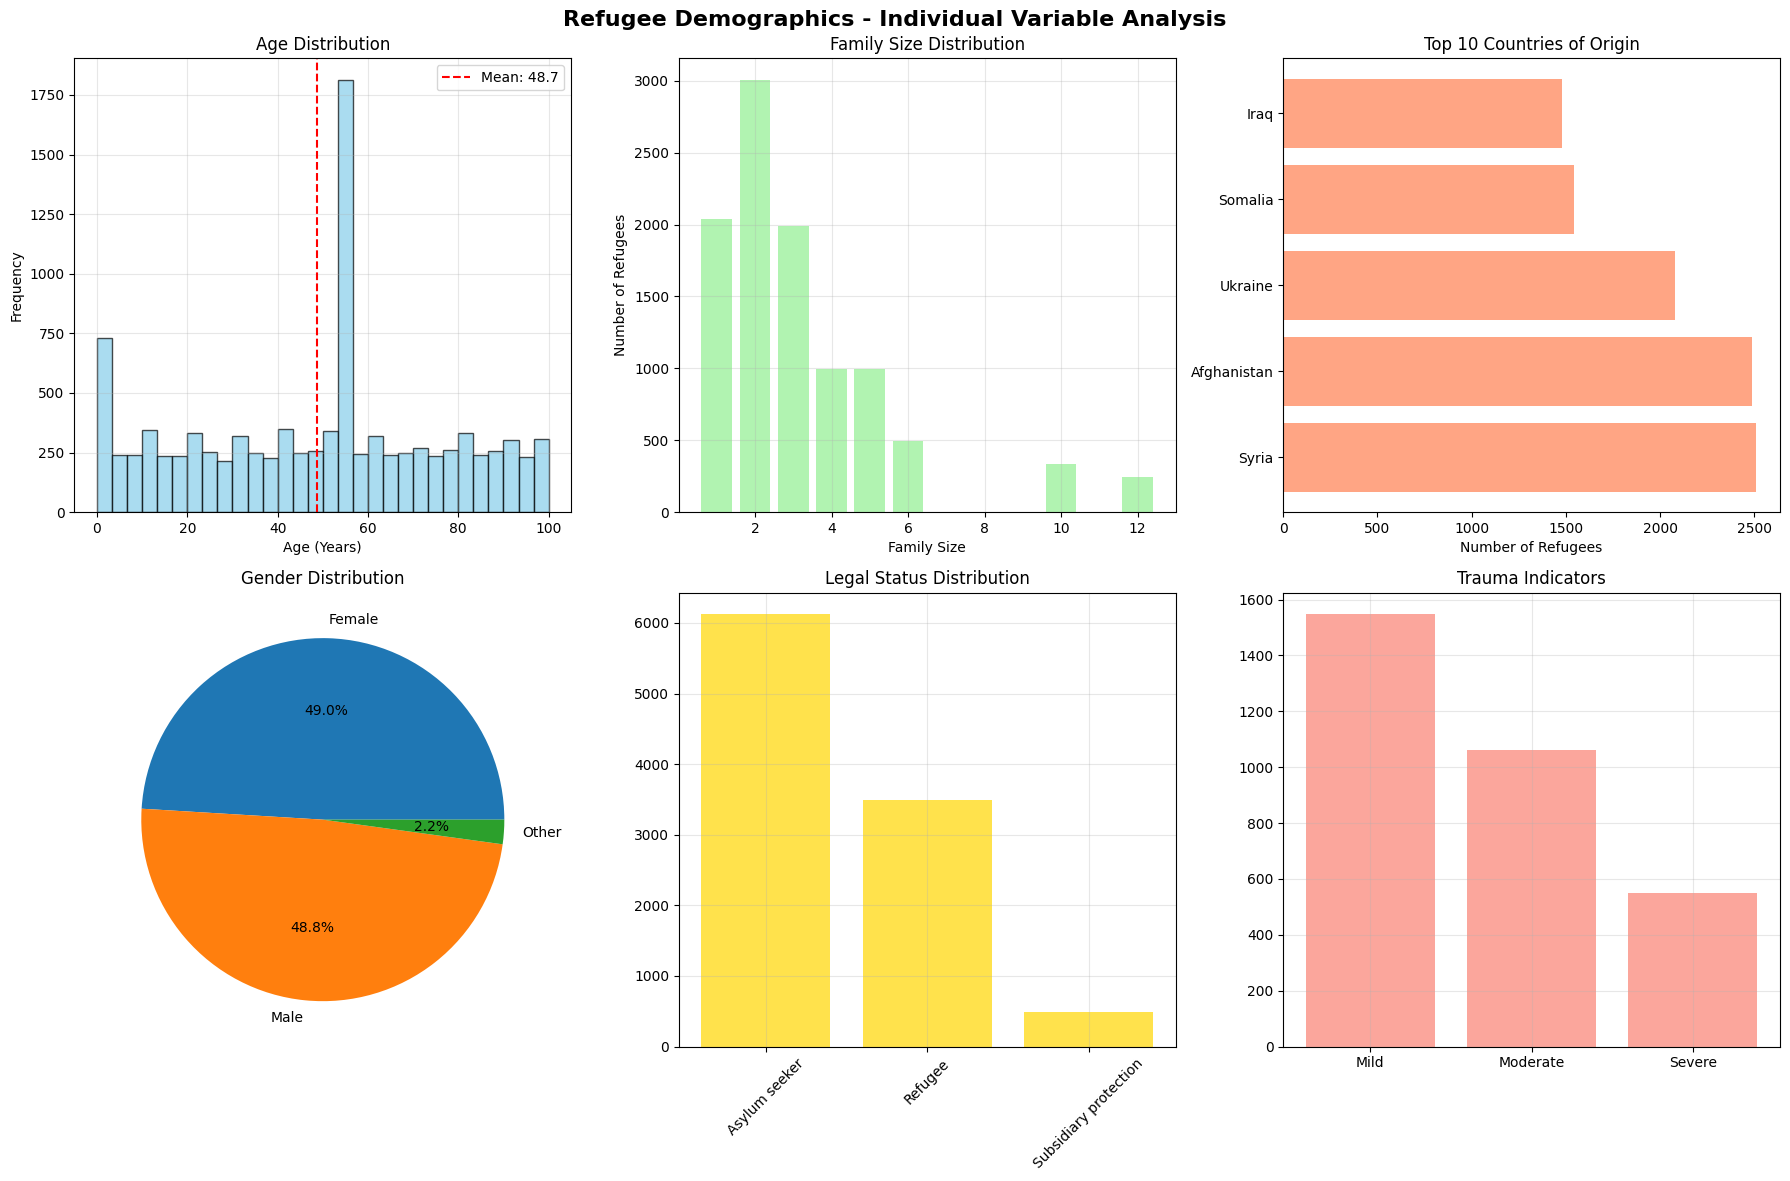

Average age: 48.7 years
Average family size: 3.2 people
Most common country: Syria
Gender split: {'Female': 4953, 'Male': 4928, 'Other': 219}


In [40]:
# Refugee Demographics Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Refugee Demographics - Individual Variable Analysis', fontsize=16, fontweight='bold')

# Age distribution
axes[0, 0].hist(refugee_df['age'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age (Years)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(refugee_df['age'].mean(), color='red', linestyle='--', 
                  label=f'Mean: {refugee_df["age"].mean():.1f}')
axes[0, 0].legend()

# Family size distribution
family_counts = refugee_df['family_size'].value_counts().sort_index()
axes[0, 1].bar(family_counts.index, family_counts.values, alpha=0.7, color='lightgreen')
axes[0, 1].set_title('Family Size Distribution')
axes[0, 1].set_xlabel('Family Size')
axes[0, 1].set_ylabel('Number of Refugees')
axes[0, 1].grid(True, alpha=0.3)

# Country of origin (top 10)
top_countries = refugee_df['country_of_origin'].value_counts().head(10)
axes[0, 2].barh(range(len(top_countries)), top_countries.values, alpha=0.7, color='coral')
axes[0, 2].set_yticks(range(len(top_countries)))
axes[0, 2].set_yticklabels(top_countries.index)
axes[0, 2].set_title('Top 10 Countries of Origin')
axes[0, 2].set_xlabel('Number of Refugees')

# Gender distribution
gender_counts = refugee_df['gender'].value_counts()
axes[1, 0].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%')
axes[1, 0].set_title('Gender Distribution')

# Legal status
legal_counts = refugee_df['legal_status'].value_counts()
axes[1, 1].bar(legal_counts.index, legal_counts.values, alpha=0.7, color='gold')
axes[1, 1].set_title('Legal Status Distribution')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

# Trauma indicators
trauma_counts = refugee_df['trauma_indicators'].value_counts()
axes[1, 2].bar(trauma_counts.index, trauma_counts.values, alpha=0.7, color='salmon')
axes[1, 2].set_title('Trauma Indicators')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print key insights
print(f"Average age: {refugee_df['age'].mean():.1f} years")
print(f"Average family size: {refugee_df['family_size'].mean():.1f} people")
print(f"Most common country: {refugee_df['country_of_origin'].mode()[0]}")
print(f"Gender split: {refugee_df['gender'].value_counts().to_dict()}")

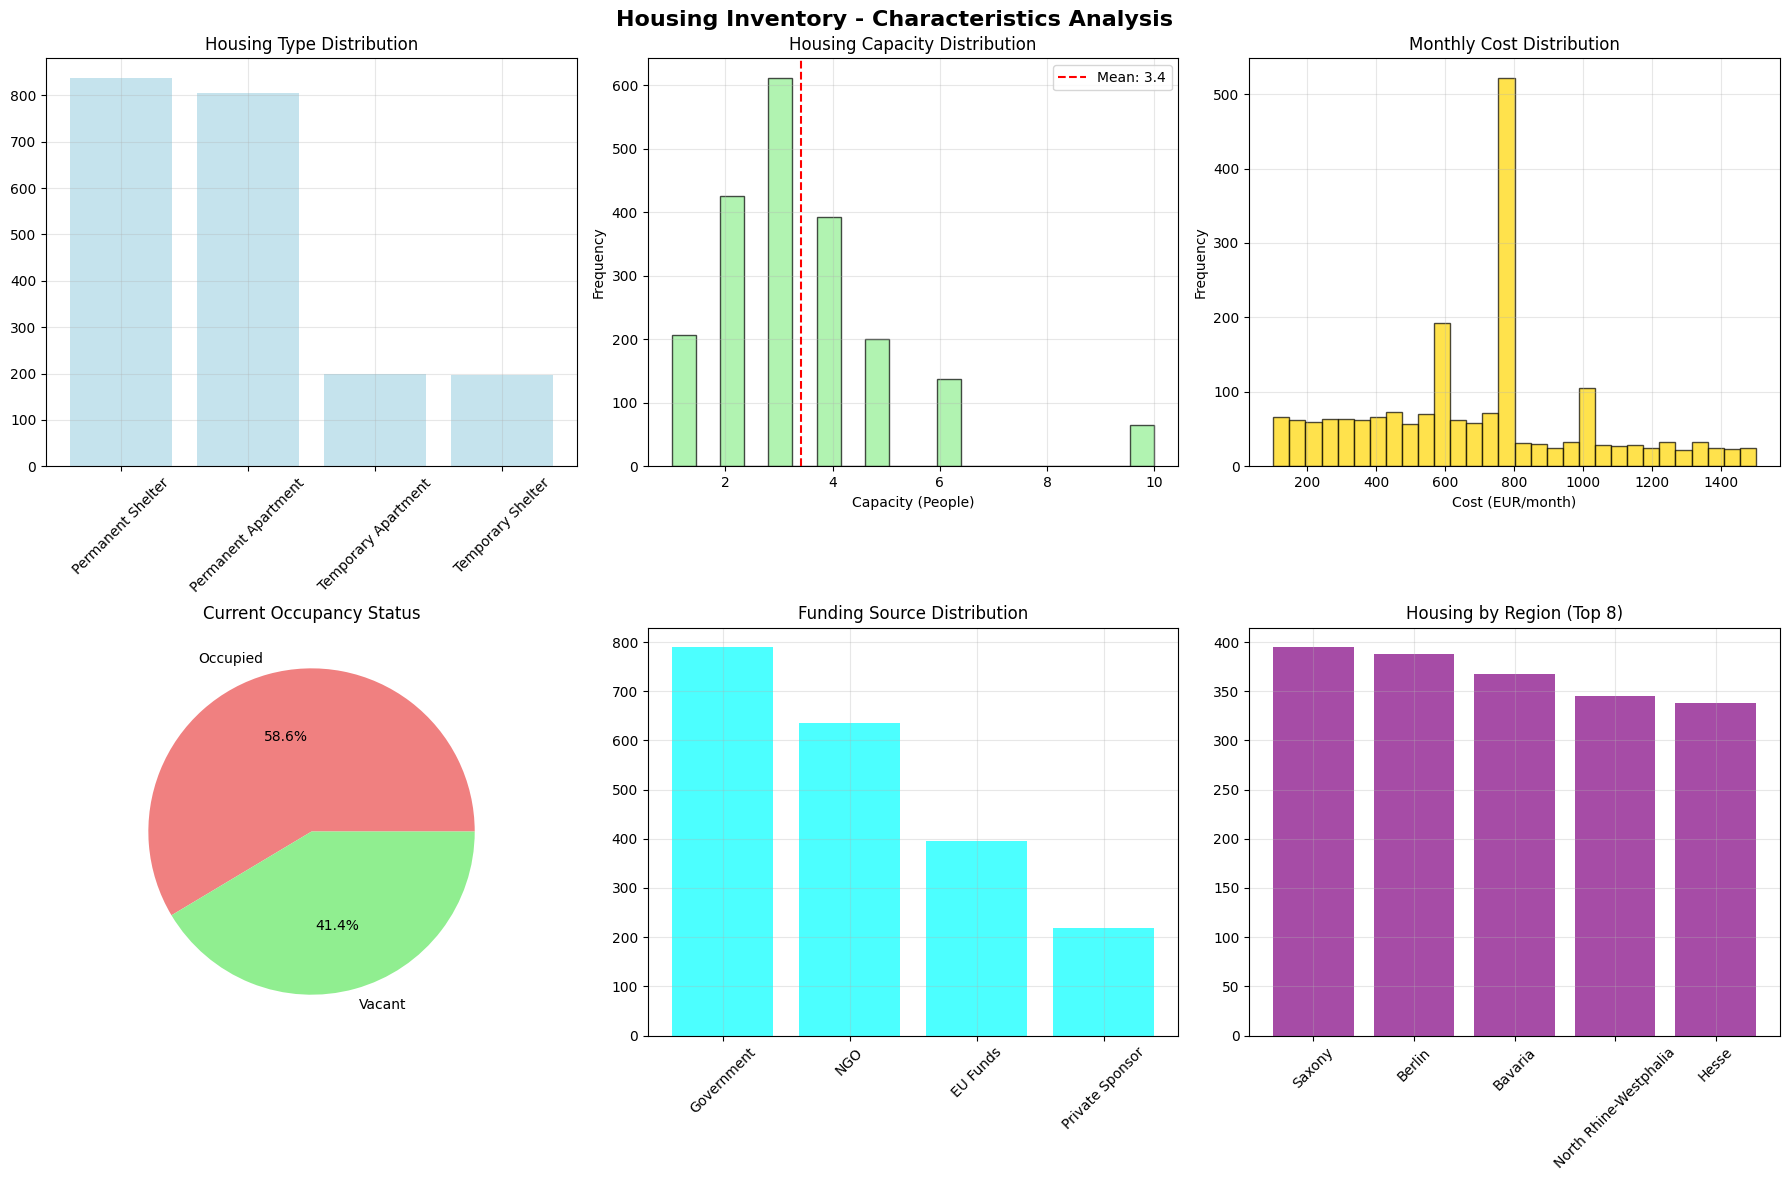


=== HOUSING INVENTORY SUMMARY ===
Total housing capacity: 6939 people
Average capacity per unit: 3.4 people
Average monthly cost: €699.83
Occupancy rate: 58.6%
Available units: 845


In [41]:
# Housing Characteristics Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Housing Inventory - Characteristics Analysis', fontsize=16, fontweight='bold')

# Housing type distribution
housing_types = housing_df['housing_type'].value_counts()
axes[0, 0].bar(housing_types.index, housing_types.values, alpha=0.7, color='lightblue')
axes[0, 0].set_title('Housing Type Distribution')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# Capacity distribution
axes[0, 1].hist(housing_df['capacity'], bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Housing Capacity Distribution')
axes[0, 1].set_xlabel('Capacity (People)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(housing_df['capacity'].mean(), color='red', linestyle='--', 
                  label=f'Mean: {housing_df["capacity"].mean():.1f}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Rental cost distribution
axes[0, 2].hist(housing_df['rental_cost_eur_per_month'], bins=30, alpha=0.7, 
               color='gold', edgecolor='black')
axes[0, 2].set_title('Monthly Cost Distribution')
axes[0, 2].set_xlabel('Cost (EUR/month)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].grid(True, alpha=0.3)

# Occupancy status
occupancy_counts = housing_df['occupancy_status'].value_counts()
axes[1, 0].pie(occupancy_counts.values, labels=occupancy_counts.index, 
              autopct='%1.1f%%', colors=['lightcoral', 'lightgreen', 'lightyellow'])
axes[1, 0].set_title('Current Occupancy Status')

# Funding source
funding_counts = housing_df['funding_source'].value_counts()
axes[1, 1].bar(funding_counts.index, funding_counts.values, alpha=0.7, color='cyan')
axes[1, 1].set_title('Funding Source Distribution')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

# Location distribution
location_counts = housing_df['location_region'].value_counts().head(8)
axes[1, 2].bar(location_counts.index, location_counts.values, alpha=0.7, color='purple')
axes[1, 2].set_title('Housing by Region (Top 8)')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n=== HOUSING INVENTORY SUMMARY ===")
print(f"Total housing capacity: {housing_df['capacity'].sum()} people")
print(f"Average capacity per unit: {housing_df['capacity'].mean():.1f} people")
print(f"Average monthly cost: €{housing_df['rental_cost_eur_per_month'].mean():.2f}")
print(f"Occupancy rate: {(housing_df['occupancy_status'] == 'Occupied').mean()*100:.1f}%")
print(f"Available units: {(housing_df['occupancy_status'] == 'Vacant').sum()}")

### Bivariate Analysis - to analyze the relationships between pairs of variables to understand how refugee characteristics relate to each other.

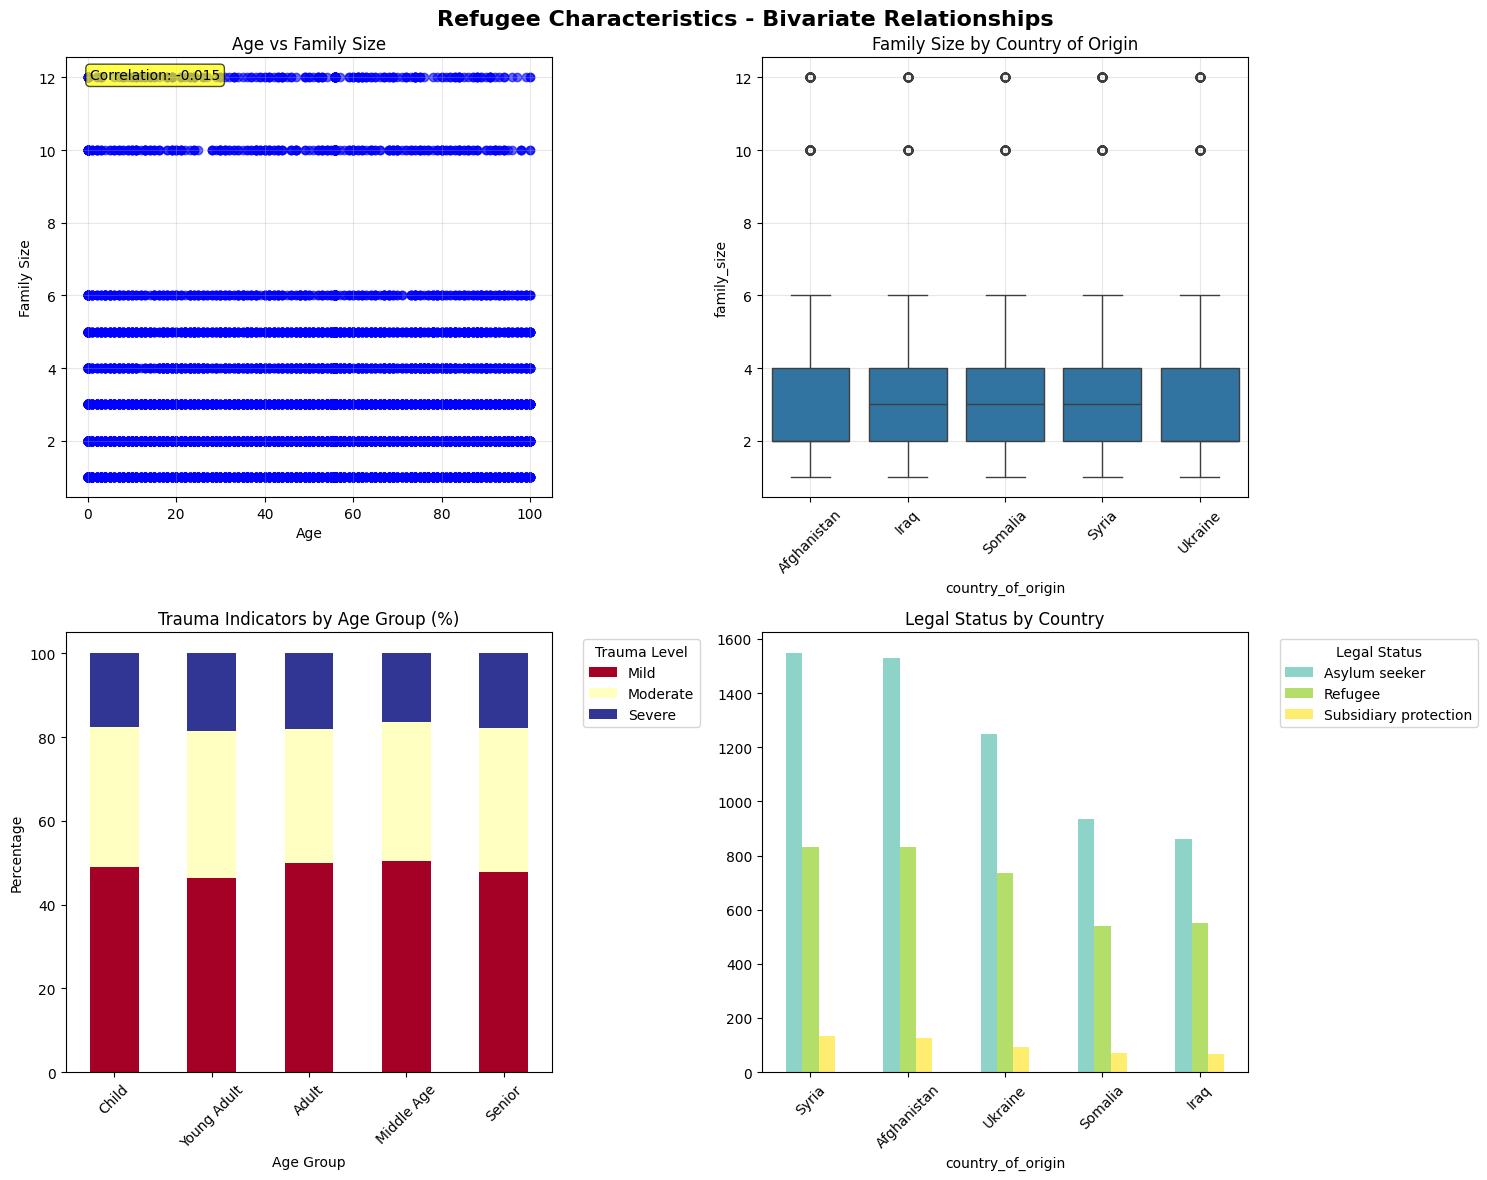

=== KEY REFUGEE RELATIONSHIPS ===
Age-Family Size Correlation: -0.015
Countries with largest families: {'Iraq': 3.22936400541272, 'Somalia': 3.2233009708737863, 'Syria': 3.2154520111509357}
Trauma prevalence by age group:
  Child: 100.0% have trauma indicators
  Young Adult: 100.0% have trauma indicators
  Adult: 100.0% have trauma indicators
  Middle Age: 100.0% have trauma indicators
  Senior: 100.0% have trauma indicators


C:\Users\sthaa\AppData\Local\Temp\ipykernel_19628\2538414547.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(f"Countries with largest families: {refugee_df.groupby('country_of_origin')['family_size'].mean().nlargest(3).to_dict()}")
C:\Users\sthaa\AppData\Local\Temp\ipykernel_19628\2538414547.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trauma_by_age = refugee_df.groupby('age_group')['trauma_indicators'].apply(lambda x: (x != 'None').mean() * 100)


In [42]:
# Refugee Characteristics Relationships
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Refugee Characteristics - Bivariate Relationships', fontsize=16, fontweight='bold')

# Age vs Family Size (important for housing capacity matching)
axes[0, 0].scatter(refugee_df['age'], refugee_df['family_size'], alpha=0.6, color='blue')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Family Size')
axes[0, 0].set_title('Age vs Family Size')
axes[0, 0].grid(True, alpha=0.3)

# Calculate and display correlation
correlation = refugee_df['age'].corr(refugee_df['family_size'])
axes[0, 0].text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
               transform=axes[0, 0].transAxes, 
               bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Family Size by Country (cultural patterns for housing needs)
top_countries = refugee_df['country_of_origin'].value_counts().head(5).index
sns.boxplot(data=refugee_df[refugee_df['country_of_origin'].isin(top_countries)], 
           x='country_of_origin', y='family_size', ax=axes[0, 1])
axes[0, 1].set_title('Family Size by Country of Origin')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3)

# Trauma by Age Group (affects housing security needs)
refugee_df['age_group'] = pd.cut(refugee_df['age'], bins=[0, 18, 35, 50, 65, 100], 
                               labels=['Child', 'Young Adult', 'Adult', 'Middle Age', 'Senior'])

trauma_age_crosstab = pd.crosstab(refugee_df['age_group'], refugee_df['trauma_indicators'])
trauma_age_pct = trauma_age_crosstab.div(trauma_age_crosstab.sum(axis=1), axis=0) * 100

trauma_age_pct.plot(kind='bar', stacked=True, ax=axes[1, 0], colormap='RdYlBu')
axes[1, 0].set_title('Trauma Indicators by Age Group (%)')
axes[1, 0].set_xlabel('Age Group')
axes[1, 0].set_ylabel('Percentage')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Trauma Level', bbox_to_anchor=(1.05, 1), loc='upper left')

# Legal Status by Country (affects housing program eligibility)
legal_country = pd.crosstab(refugee_df['country_of_origin'], refugee_df['legal_status'])
legal_country_top = legal_country.loc[top_countries]
legal_country_top.plot(kind='bar', ax=axes[1, 1], colormap='Set3')
axes[1, 1].set_title('Legal Status by Country')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(title='Legal Status', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Print key relationships
print("=== KEY REFUGEE RELATIONSHIPS ===")
print(f"Age-Family Size Correlation: {correlation:.3f}")
print(f"Countries with largest families: {refugee_df.groupby('country_of_origin')['family_size'].mean().nlargest(3).to_dict()}")
print(f"Trauma prevalence by age group:")
trauma_by_age = refugee_df.groupby('age_group')['trauma_indicators'].apply(lambda x: (x != 'None').mean() * 100)
for age_group, pct in trauma_by_age.items():
    print(f"  {age_group}: {pct:.1f}% have trauma indicators")

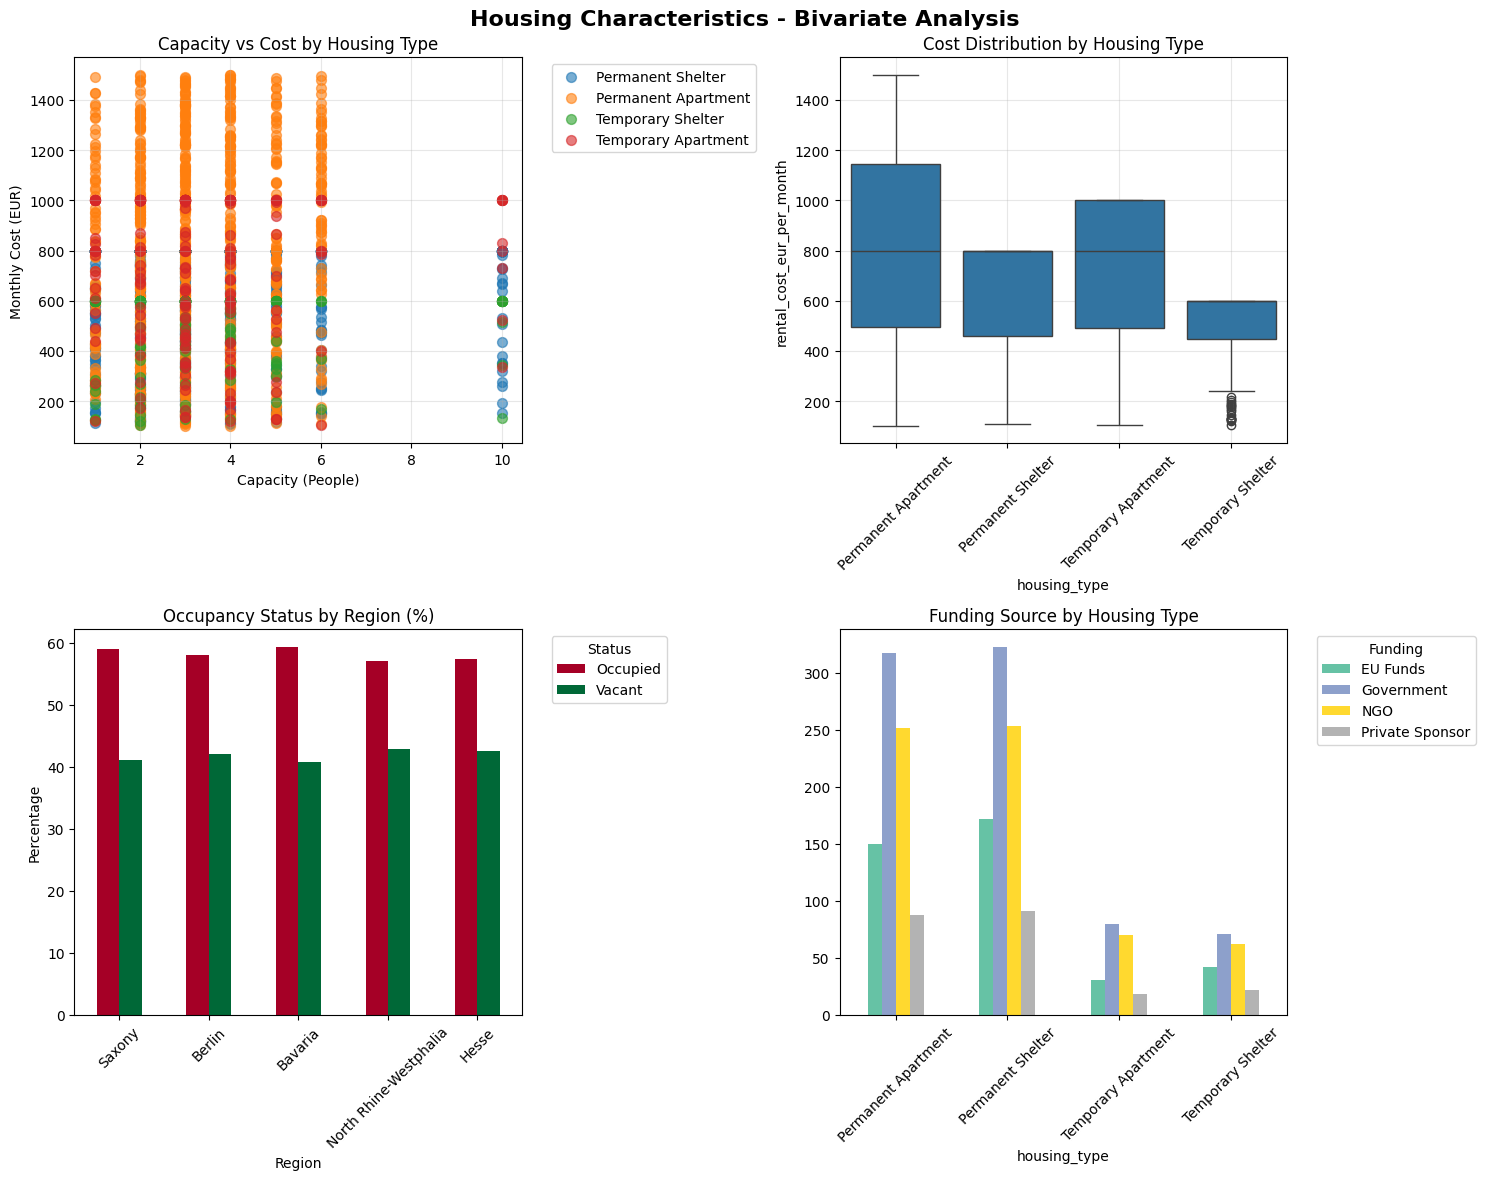

=== HOUSING COST EFFICIENCY ===
Average cost per person by housing type:
  Permanent Apartment: €309.35/person/month
  Permanent Shelter: €244.14/person/month
  Temporary Apartment: €290.25/person/month
  Temporary Shelter: €188.45/person/month

Most cost-efficient: Temporary Shelter (€188.45/person)
Most expensive: Permanent Apartment (€309.35/person)


C:\Users\sthaa\AppData\Local\Temp\ipykernel_19628\1874281089.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cost_per_person = housing_df.groupby('housing_type').apply(
C:\Users\sthaa\AppData\Local\Temp\ipykernel_19628\1874281089.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cost_per_person = housing_df.groupby('housing_type').apply(


In [43]:
# Housing Characteristics Relationships
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Housing Characteristics - Bivariate Analysis', fontsize=16, fontweight='bold')

# Capacity vs Cost by Housing Type (cost efficiency analysis)
for housing_type in housing_df['housing_type'].unique():
    subset = housing_df[housing_df['housing_type'] == housing_type]
    axes[0, 0].scatter(subset['capacity'], subset['rental_cost_eur_per_month'], 
                      label=housing_type, alpha=0.6, s=50)

axes[0, 0].set_xlabel('Capacity (People)')
axes[0, 0].set_ylabel('Monthly Cost (EUR)')
axes[0, 0].set_title('Capacity vs Cost by Housing Type')
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 0].grid(True, alpha=0.3)

# Cost Distribution by Housing Type (budget planning)
sns.boxplot(data=housing_df, x='housing_type', y='rental_cost_eur_per_month', ax=axes[0, 1])
axes[0, 1].set_title('Cost Distribution by Housing Type')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3)

# Occupancy by Region (demand patterns)
occupancy_region = pd.crosstab(housing_df['location_region'], housing_df['occupancy_status'])
occupancy_region_pct = occupancy_region.div(occupancy_region.sum(axis=1), axis=0) * 100

# Plot top 6 regions
top_regions = housing_df['location_region'].value_counts().head(6).index
occupancy_region_pct.loc[top_regions].plot(kind='bar', ax=axes[1, 0], colormap='RdYlGn')
axes[1, 0].set_title('Occupancy Status by Region (%)')
axes[1, 0].set_xlabel('Region')
axes[1, 0].set_ylabel('Percentage')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Funding vs Housing Type (resource allocation)
funding_housing = pd.crosstab(housing_df['housing_type'], housing_df['funding_source'])
funding_housing.plot(kind='bar', ax=axes[1, 1], colormap='Set2')
axes[1, 1].set_title('Funding Source by Housing Type')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(title='Funding', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Calculate cost efficiency metrics
print("=== HOUSING COST EFFICIENCY ===")
cost_per_person = housing_df.groupby('housing_type').apply(
    lambda x: (x['rental_cost_eur_per_month'] / x['capacity']).mean()
)
print("Average cost per person by housing type:")
for housing_type, cost in cost_per_person.items():
    print(f"  {housing_type}: €{cost:.2f}/person/month")

print(f"\nMost cost-efficient: {cost_per_person.idxmin()} (€{cost_per_person.min():.2f}/person)")
print(f"Most expensive: {cost_per_person.idxmax()} (€{cost_per_person.max():.2f}/person)")

#### Time Based Analysis

In [44]:
# Add time-based features for analysis
refugee_df['arrival_year'] = refugee_df['date_of_arrival'].dt.year
refugee_df['arrival_month'] = refugee_df['date_of_arrival'].dt.month
refugee_df['arrival_quarter'] = refugee_df['date_of_arrival'].dt.quarter

Annual Arrival Trends

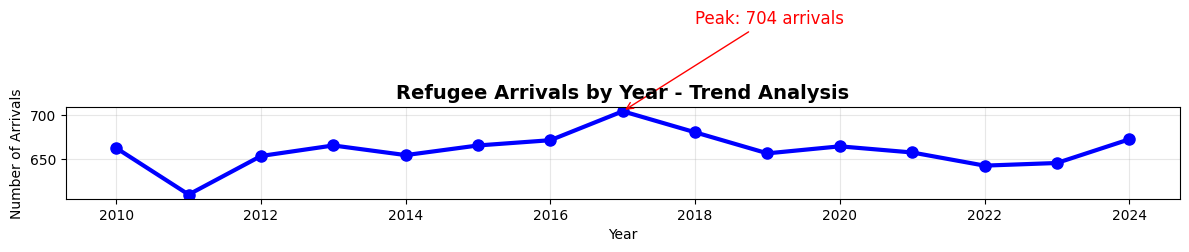

Peak arrival year: 2017.0 with 704 arrivals
Total arrivals over 15 years: 9899
Average arrivals per year: 660


In [45]:
# Arrivals by year - shows major crisis periods
plt.figure(figsize=(12, 6))
yearly_arrivals = refugee_df['arrival_year'].value_counts().sort_index()
plt.plot(yearly_arrivals.index, yearly_arrivals.values, marker='o', linewidth=3, markersize=8, color='blue')
plt.title('Refugee Arrivals by Year - Trend Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Arrivals')
plt.grid(True, alpha=0.3)

# Add annotations for peak years
max_year = yearly_arrivals.idxmax()
max_count = yearly_arrivals.max()
plt.annotate(f'Peak: {max_count} arrivals', 
             xy=(max_year, max_count), 
             xytext=(max_year + 1, max_count + 100),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=12, color='red')

plt.tight_layout()
plt.show()

print(f"Peak arrival year: {max_year} with {max_count} arrivals")
print(f"Total arrivals over {len(yearly_arrivals)} years: {yearly_arrivals.sum()}")
print(f"Average arrivals per year: {yearly_arrivals.mean():.0f}")

Seasonal Patterns

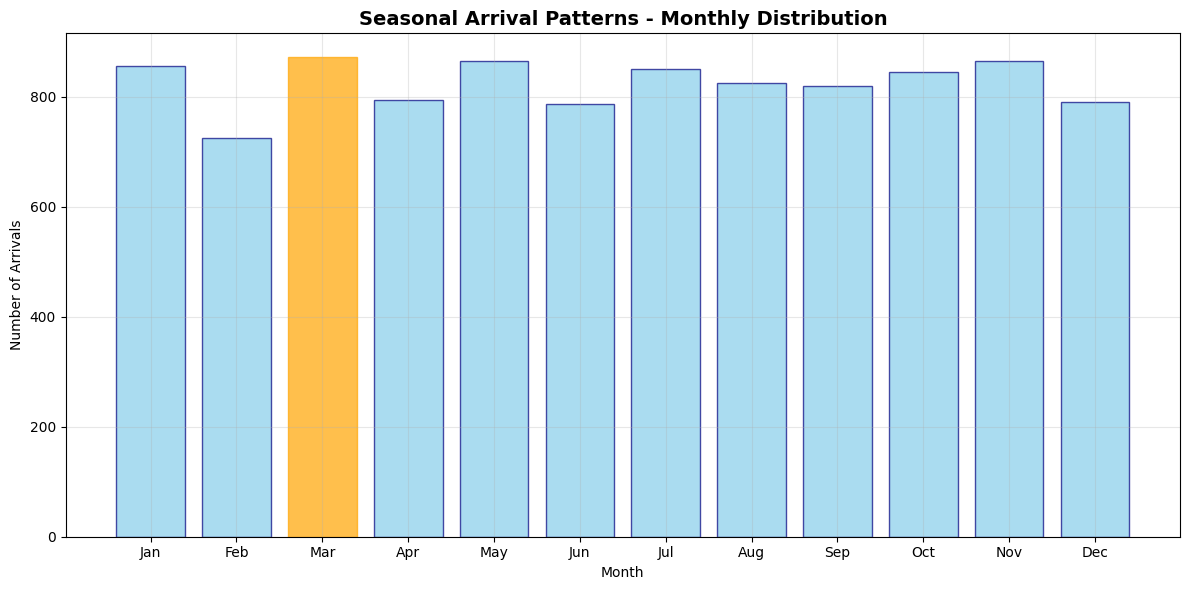

Peak arrival month: Mar with 872 arrivals
Lowest arrival month: Feb with 725 arrivals
Seasonal variation: 17.8% above average


In [46]:
# Monthly arrivals - seasonal patterns for resource planning
plt.figure(figsize=(12, 6))
monthly_arrivals = refugee_df['arrival_month'].value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

bars = plt.bar(range(1, 13), [monthly_arrivals.get(i, 0) for i in range(1, 13)], 
               alpha=0.7, color='skyblue', edgecolor='navy')
plt.xticks(range(1, 13), month_names)
plt.title('Seasonal Arrival Patterns - Monthly Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Arrivals')
plt.grid(True, alpha=0.3)

# Fix: Convert to integer and handle any missing data
peak_month = int(monthly_arrivals.idxmax())  # Convert to int
peak_count = monthly_arrivals.max()
bars[peak_month - 1].set_color('orange')

plt.tight_layout()
plt.show()

print(f"Peak arrival month: {month_names[peak_month-1]} with {peak_count} arrivals")
print(f"Lowest arrival month: {month_names[int(monthly_arrivals.idxmin())-1]} with {monthly_arrivals.min()} arrivals")
print(f"Seasonal variation: {((peak_count - monthly_arrivals.min()) / monthly_arrivals.mean() * 100):.1f}% above average")

Country Specific Arrival Trends

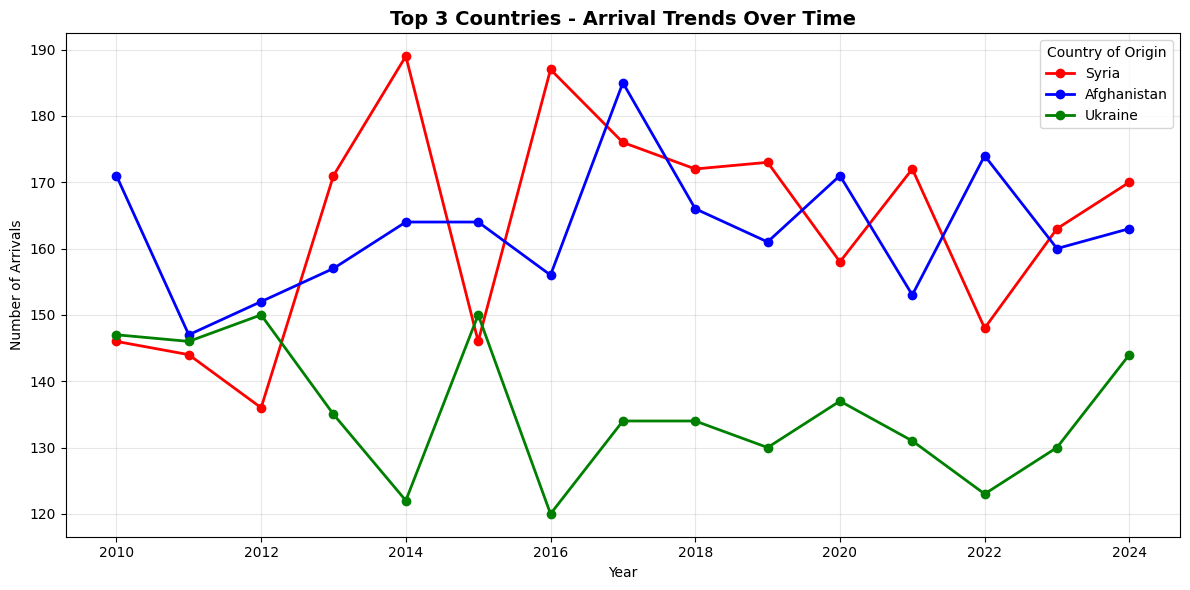

Country-specific arrival patterns:
  Syria: Peak in 2014.0 (189 arrivals)
  Afghanistan: Peak in 2017.0 (185 arrivals)
  Ukraine: Peak in 2012.0 (150 arrivals)


In [47]:
# Top 3 countries over time - shows crisis patterns by origin
plt.figure(figsize=(12, 6))
top_3_countries = refugee_df['country_of_origin'].value_counts().head(3).index

colors = ['red', 'blue', 'green']
for i, country in enumerate(top_3_countries):
    country_data = refugee_df[refugee_df['country_of_origin'] == country]
    country_yearly = country_data['arrival_year'].value_counts().sort_index()
    plt.plot(country_yearly.index, country_yearly.values, marker='o', 
             label=country, linewidth=2, color=colors[i], markersize=6)

plt.title('Top 3 Countries - Arrival Trends Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Arrivals')
plt.legend(title='Country of Origin')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Country-specific arrival patterns:")
for country in top_3_countries:
    country_data = refugee_df[refugee_df['country_of_origin'] == country]
    country_yearly = country_data['arrival_year'].value_counts().sort_index()
    peak_year = country_yearly.idxmax()
    peak_arrivals = country_yearly.max()
    print(f"  {country}: Peak in {peak_year} ({peak_arrivals} arrivals)")

Family size trends over time

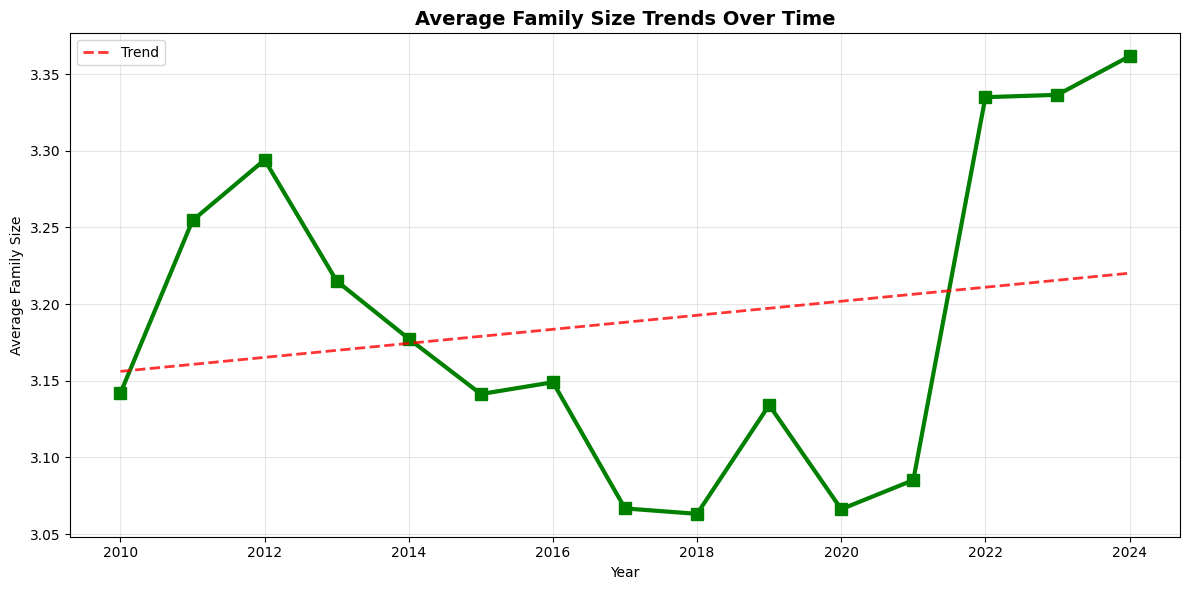

Family size trend: +0.22 change from 3.14 to 3.36
Families are getting larger over time - need more high-capacity housing


In [48]:
# Average family size changes over time - demographic shifts
plt.figure(figsize=(12, 6))
family_time = refugee_df.groupby('arrival_year')['family_size'].mean()
plt.plot(family_time.index, family_time.values, marker='s', 
         color='green', linewidth=3, markersize=8)
plt.title('Average Family Size Trends Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Family Size')
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(family_time.index, family_time.values, 1)
p = np.poly1d(z)
plt.plot(family_time.index, p(family_time.index), "r--", alpha=0.8, linewidth=2, label='Trend')
plt.legend()

plt.tight_layout()
plt.show()

# Calculate trend
trend_change = family_time.iloc[-1] - family_time.iloc[0]
print(f"Family size trend: {trend_change:+.2f} change from {family_time.iloc[0]:.2f} to {family_time.iloc[-1]:.2f}")
if trend_change > 0:
    print("Families are getting larger over time - need more high-capacity housing")
else:
    print("Families are getting smaller over time - need more small-capacity housing")

### Correlation Matrix

Refugee

Numerical refugee features: ['age', 'family_size', 'arrival_year', 'arrival_month', 'arrival_quarter']


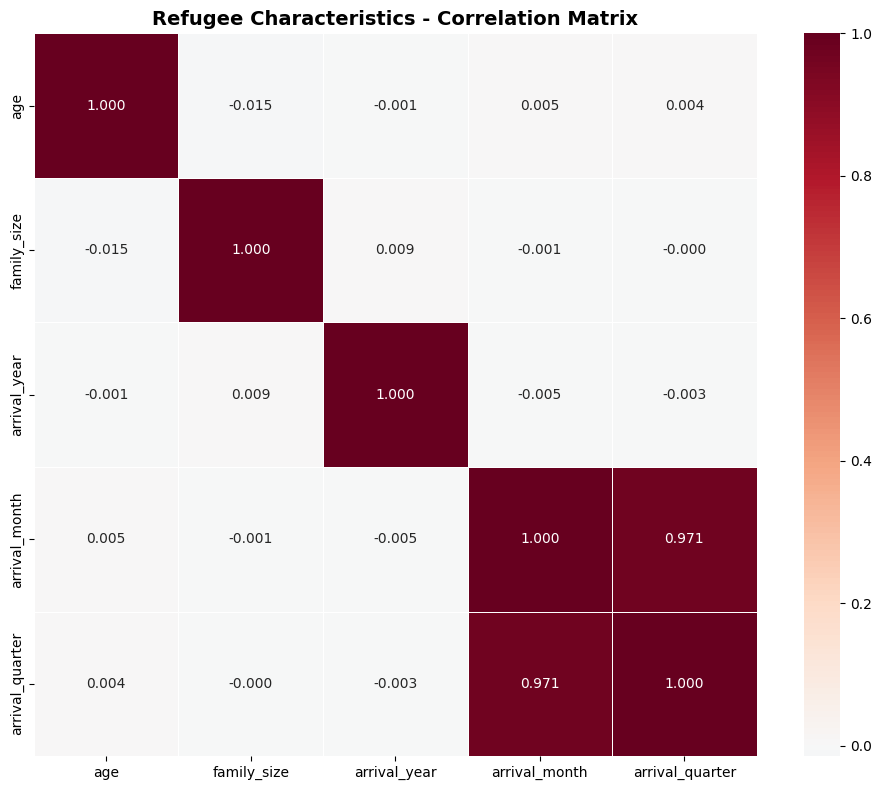

=== STRONGEST REFUGEE CORRELATIONS ===
Top correlations (excluding perfect 1.0):
  arrival_quarter ↔ arrival_month: 0.971
  family_size ↔ age: -0.015
  arrival_year ↔ family_size: 0.009
  arrival_month ↔ age: 0.005
  arrival_month ↔ arrival_year: -0.005
  arrival_quarter ↔ age: 0.004
  arrival_quarter ↔ arrival_year: -0.003
  arrival_month ↔ family_size: -0.001


In [49]:
# Select numerical columns for refugee data
refugee_numeric = refugee_df.select_dtypes(include=[np.number])
print("Numerical refugee features:", refugee_numeric.columns.tolist())

# Create correlation matrix
plt.figure(figsize=(10, 8))
refugee_corr = refugee_numeric.corr()
sns.heatmap(refugee_corr, annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.3f', linewidths=0.5)
plt.title('Refugee Characteristics - Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Find strongest correlations
print("=== STRONGEST REFUGEE CORRELATIONS ===")
# Get upper triangle of correlation matrix to avoid duplicates
upper_triangle = refugee_corr.where(np.triu(np.ones(refugee_corr.shape), k=1).astype(bool))
correlations = upper_triangle.unstack().dropna().sort_values(key=abs, ascending=False)

print("Top correlations (excluding perfect 1.0):")
for (var1, var2), corr in correlations.head(8).items():
    print(f"  {var1} ↔ {var2}: {corr:.3f}")

Housing

Numerical housing features: ['housing_id', 'capacity', 'proximity_to_services_km', 'rental_cost_eur_per_month', 'community_size']


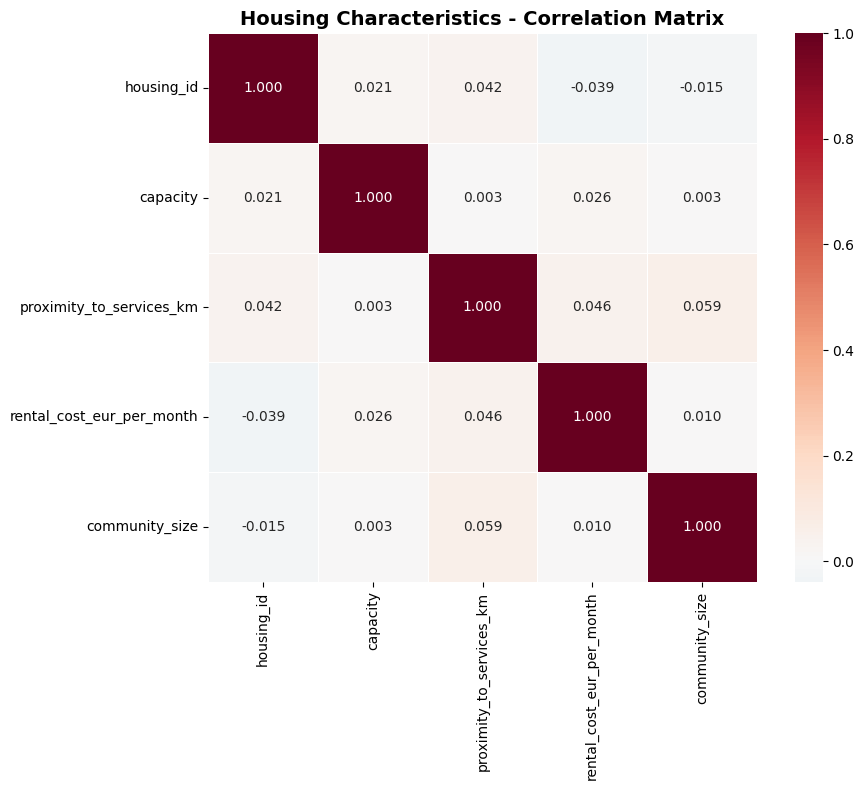

=== STRONGEST HOUSING CORRELATIONS ===
Top correlations:
  community_size ↔ proximity_to_services_km: 0.059
  rental_cost_eur_per_month ↔ proximity_to_services_km: 0.046
  proximity_to_services_km ↔ housing_id: 0.042
  rental_cost_eur_per_month ↔ housing_id: -0.039
  rental_cost_eur_per_month ↔ capacity: 0.026
  capacity ↔ housing_id: 0.021
  community_size ↔ housing_id: -0.015
  community_size ↔ rental_cost_eur_per_month: 0.010


In [50]:
# Select numerical columns for housing data
housing_numeric = housing_df.select_dtypes(include=[np.number])
print("Numerical housing features:", housing_numeric.columns.tolist())

# Create correlation matrix
plt.figure(figsize=(10, 8))
housing_corr = housing_numeric.corr()
sns.heatmap(housing_corr, annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.3f', linewidths=0.5)
plt.title('Housing Characteristics - Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Find strongest correlations
print("=== STRONGEST HOUSING CORRELATIONS ===")
upper_triangle_housing = housing_corr.where(np.triu(np.ones(housing_corr.shape), k=1).astype(bool))
housing_correlations = upper_triangle_housing.unstack().dropna().sort_values(key=abs, ascending=False)

print("Top correlations:")
for (var1, var2), corr in housing_correlations.head(8).items():
    print(f"  {var1} ↔ {var2}: {corr:.3f}")

## Housing Demand Analysis

Supply Demand Analysis

=== OVERALL SUPPLY-DEMAND ANALYSIS ===
Total housing capacity: 6939 people
Total refugees: 10100
Average family size: 3.19
Housing units needed: 3167
Capacity utilization: 145.6%


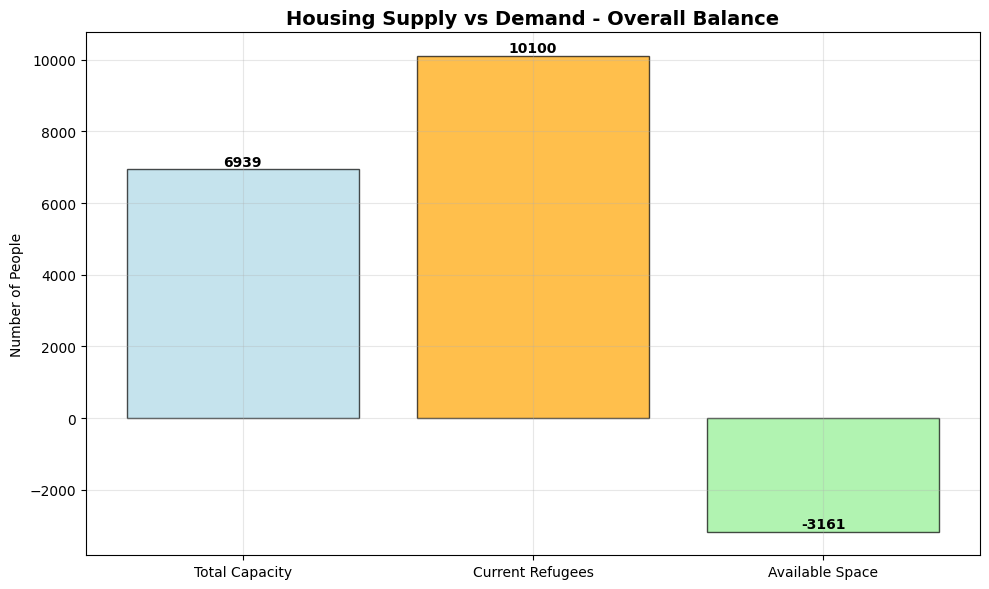

⚠️  Housing shortage: 3161 people over capacity


In [51]:
# Calculate basic supply-demand metrics
total_housing_capacity = housing_df['capacity'].sum()
total_refugees = len(refugee_df)
avg_family_size = refugee_df['family_size'].mean()
housing_units_needed = total_refugees / avg_family_size

print("=== OVERALL SUPPLY-DEMAND ANALYSIS ===")
print(f"Total housing capacity: {total_housing_capacity} people")
print(f"Total refugees: {total_refugees}")
print(f"Average family size: {avg_family_size:.2f}")
print(f"Housing units needed: {housing_units_needed:.0f}")
print(f"Capacity utilization: {(total_refugees/total_housing_capacity)*100:.1f}%")

# Visualize overall balance
plt.figure(figsize=(10, 6))
categories = ['Total Capacity', 'Current Refugees', 'Available Space']
values = [total_housing_capacity, total_refugees, total_housing_capacity - total_refugees]
colors = ['lightblue', 'orange', 'lightgreen']

bars = plt.bar(categories, values, color=colors, alpha=0.7, edgecolor='black')
plt.title('Housing Supply vs Demand - Overall Balance', fontsize=14, fontweight='bold')
plt.ylabel('Number of People')
plt.grid(True, alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{value}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

if total_housing_capacity > total_refugees:
    print(f"✅ Sufficient capacity: {total_housing_capacity - total_refugees} extra spaces")
else:
    print(f"⚠️  Housing shortage: {total_refugees - total_housing_capacity} people over capacity")

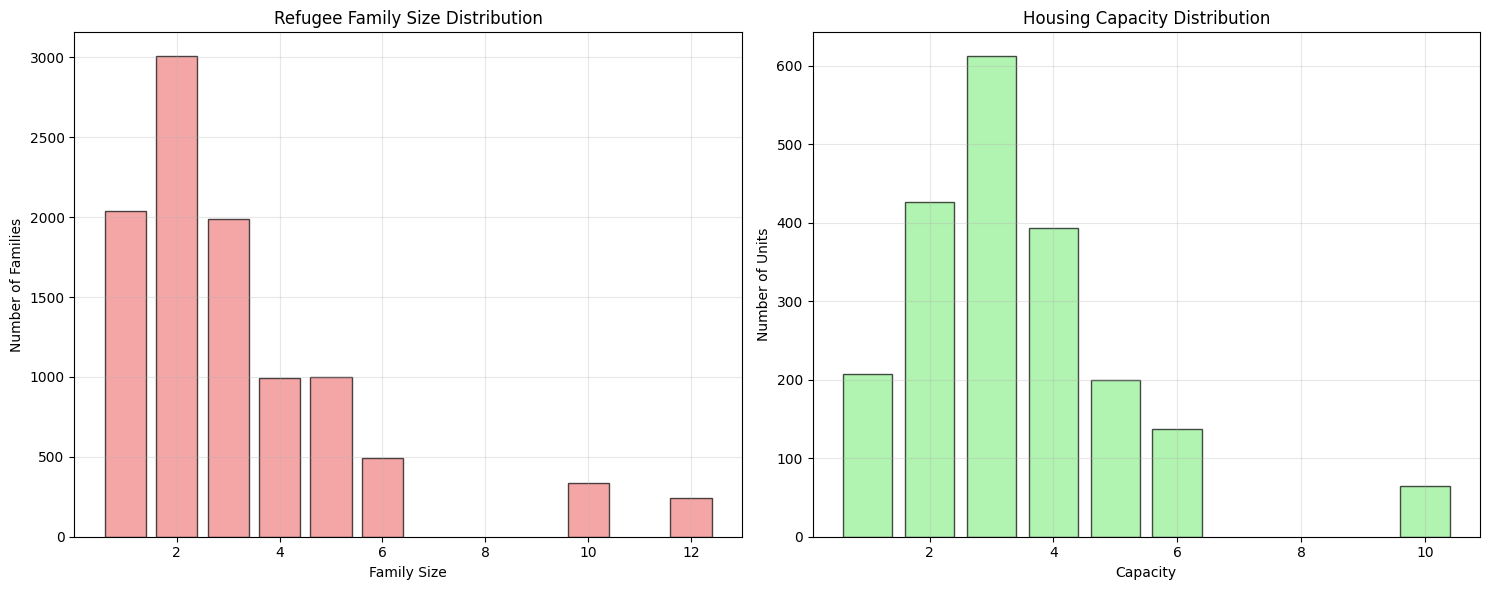

=== FAMILY-HOUSING SIZE MATCHING ANALYSIS ===

Family size distribution:
  Size 1: 2041 families (20.2%)
  Size 2: 3006 families (29.8%)
  Size 3: 1989 families (19.7%)
  Size 4: 993 families (9.8%)
  Size 5: 999 families (9.9%)
  Size 6: 494 families (4.9%)

Housing capacity distribution:
  Capacity 1: 207 units (10.1%)
  Capacity 2: 426 units (20.9%)
  Capacity 3: 612 units (30.0%)
  Capacity 4: 393 units (19.3%)
  Capacity 5: 200 units (9.8%)
  Capacity 6: 137 units (6.7%)

Potential Matching Challenges:
Large families (>6 people): 578 families
Large capacity housing (>6 capacity): 65 units
⚠️  Shortage: 513 large families may need multiple units


In [52]:
# Analyze how well family sizes match available housing capacities
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Family size distribution
family_size_dist = refugee_df['family_size'].value_counts().sort_index()
ax1.bar(family_size_dist.index, family_size_dist.values, alpha=0.7, 
        color='lightcoral', edgecolor='black')
ax1.set_title('Refugee Family Size Distribution')
ax1.set_xlabel('Family Size')
ax1.set_ylabel('Number of Families')
ax1.grid(True, alpha=0.3)

# Housing capacity distribution
housing_capacity_dist = housing_df['capacity'].value_counts().sort_index()
ax2.bar(housing_capacity_dist.index, housing_capacity_dist.values, alpha=0.7, 
        color='lightgreen', edgecolor='black')
ax2.set_title('Housing Capacity Distribution')
ax2.set_xlabel('Capacity')
ax2.set_ylabel('Number of Units')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate matching efficiency
print("=== FAMILY-HOUSING SIZE MATCHING ANALYSIS ===")
print("\nFamily size distribution:")
for size, count in family_size_dist.head(6).items():
    percentage = (count / len(refugee_df)) * 100
    print(f"  Size {size}: {count} families ({percentage:.1f}%)")

print("\nHousing capacity distribution:")
for capacity, count in housing_capacity_dist.head(6).items():
    percentage = (count / len(housing_df)) * 100
    print(f"  Capacity {capacity}: {count} units ({percentage:.1f}%)")

# Identify potential mismatches
large_families = refugee_df[refugee_df['family_size'] > 6]
large_capacity_housing = housing_df[housing_df['capacity'] > 6]

print(f"\nPotential Matching Challenges:")
print(f"Large families (>6 people): {len(large_families)} families")
print(f"Large capacity housing (>6 capacity): {len(large_capacity_housing)} units")

if len(large_families) > len(large_capacity_housing):
    print(f"⚠️  Shortage: {len(large_families) - len(large_capacity_housing)} large families may need multiple units")
else:
    print(f"✅ Sufficient large housing for big families")

Thus, dataset in its current state is well-tuned for small to medium families but underserved for very large families

Cost based demand Analysis

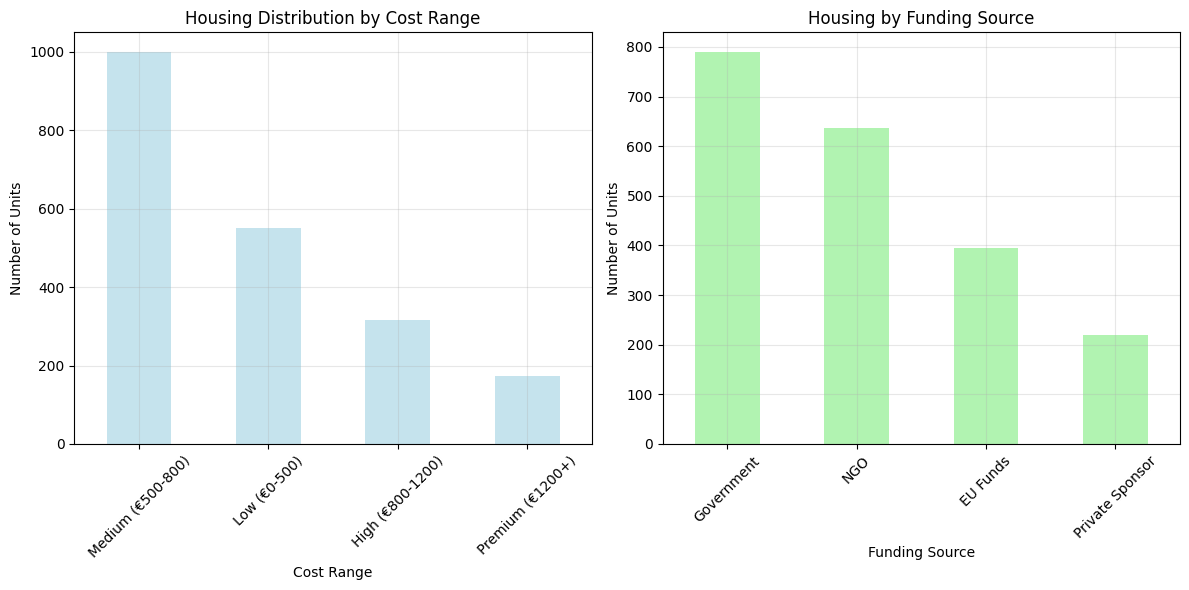

=== COST AND FUNDING ANALYSIS ===
Average housing cost: €699.83/month
Total monthly housing cost: €1,427,651.83

Cost distribution:
  Medium (€500-800): 1000 units (49.0%)
  Low (€0-500): 550 units (27.0%)
  High (€800-1200): 317 units (15.5%)
  Premium (€1200+): 173 units (8.5%)

Funding distribution:
  Government: 790 units (38.7%) - Avg: €699.64
  NGO: 636 units (31.2%) - Avg: €703.64
  EU Funds: 395 units (19.4%) - Avg: €697.59
  Private Sponsor: 219 units (10.7%) - Avg: €693.49


In [53]:
# Analyze housing costs vs funding availability
plt.figure(figsize=(12, 6))

# Group housing by cost ranges
housing_df['cost_range'] = pd.cut(housing_df['rental_cost_eur_per_month'], 
                                 bins=[0, 500, 800, 1200, 2000], 
                                 labels=['Low (€0-500)', 'Medium (€500-800)', 
                                        'High (€800-1200)', 'Premium (€1200+)'])

cost_distribution = housing_df['cost_range'].value_counts()
funding_distribution = housing_df['funding_source'].value_counts()

# Cost range distribution
ax1 = plt.subplot(1, 2, 1)
cost_distribution.plot(kind='bar', ax=ax1, color='lightblue', alpha=0.7)
plt.title('Housing Distribution by Cost Range')
plt.xlabel('Cost Range')
plt.ylabel('Number of Units')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Funding source distribution
ax2 = plt.subplot(1, 2, 2)
funding_distribution.plot(kind='bar', ax=ax2, color='lightgreen', alpha=0.7)
plt.title('Housing by Funding Source')
plt.xlabel('Funding Source')
plt.ylabel('Number of Units')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=== COST AND FUNDING ANALYSIS ===")
avg_cost = housing_df['rental_cost_eur_per_month'].mean()
total_monthly_cost = housing_df['rental_cost_eur_per_month'].sum()

print(f"Average housing cost: €{avg_cost:.2f}/month")
print(f"Total monthly housing cost: €{total_monthly_cost:,.2f}")

print(f"\nCost distribution:")
for cost_range, count in cost_distribution.items():
    percentage = (count / len(housing_df)) * 100
    print(f"  {cost_range}: {count} units ({percentage:.1f}%)")

print(f"\nFunding distribution:")
for funding_source, count in funding_distribution.items():
    percentage = (count / len(housing_df)) * 100
    avg_cost_by_funding = housing_df[housing_df['funding_source'] == funding_source]['rental_cost_eur_per_month'].mean()
    print(f"  {funding_source}: {count} units ({percentage:.1f}%) - Avg: €{avg_cost_by_funding:.2f}")

### Key Insights

In [54]:
# Calculate key demographic statistics
avg_age = refugee_df['age'].mean()
avg_family = refugee_df['family_size'].mean()
most_common_country = refugee_df['country_of_origin'].mode()[0]
most_common_legal_status = refugee_df['legal_status'].mode()[0]

print("\n1. DEMOGRAPHIC PATTERNS FOR PREDICTION:")
print(f"   • Average refugee age: {avg_age:.1f} years")
print(f"   • Average family size: {avg_family:.1f} people")
print(f"   • Most common origin: {most_common_country}")
print(f"   • Most common legal status: {most_common_legal_status}")

# Age group analysis for housing needs
age_groups = refugee_df['age_group'].value_counts()
print(f"\n   Age group distribution:")
for group, count in age_groups.items():
    percentage = (count / len(refugee_df)) * 100
    print(f"     - {group}: {percentage:.1f}%")

# Family size implications
family_stats = refugee_df['family_size'].describe()
print(f"\n   Family size insights:")
print(f"     - 50% of families: {family_stats['50%']:.0f} people or smaller")
print(f"     - 75% of families: {family_stats['75%']:.0f} people or smaller")
print(f"     - Large families (>6): {(refugee_df['family_size'] > 6).sum()} families")



1. DEMOGRAPHIC PATTERNS FOR PREDICTION:
   • Average refugee age: 48.7 years
   • Average family size: 3.2 people
   • Most common origin: Syria
   • Most common legal status: Asylum seeker

   Age group distribution:
     - Middle Age: 27.6%
     - Senior: 27.3%
     - Child: 14.2%
     - Young Adult: 13.5%
     - Adult: 12.5%

   Family size insights:
     - 50% of families: 3 people or smaller
     - 75% of families: 4 people or smaller
     - Large families (>6): 578 families


In [55]:
# Housing characteristics for AI matching
avg_capacity = housing_df['capacity'].mean()
avg_cost = housing_df['rental_cost_eur_per_month'].mean()
occupancy_rate = (housing_df['occupancy_status'] == 'Occupied').mean() * 100

print("\n2. HOUSING SUPPLY CHARACTERISTICS:")
print(f"   • Total housing units: {len(housing_df)}")
print(f"   • Average capacity: {avg_capacity:.1f} people")
print(f"   • Average monthly cost: €{avg_cost:.2f}")
print(f"   • Current occupancy rate: {occupancy_rate:.1f}%")
print(f"   • Available units: {(housing_df['occupancy_status'] == 'Vacant').sum()}")

# Housing type distribution
housing_types = housing_df['housing_type'].value_counts()
print(f"\n   Housing type distribution:")
for housing_type, count in housing_types.items():
    percentage = (count / len(housing_df)) * 100
    avg_type_cost = housing_df[housing_df['housing_type'] == housing_type]['rental_cost_eur_per_month'].mean()
    print(f"     - {housing_type}: {percentage:.1f}% (Avg: €{avg_type_cost:.0f})")

# Cost efficiency analysis
housing_df['cost_per_person'] = housing_df['rental_cost_eur_per_month'] / housing_df['capacity']
most_efficient = housing_df.groupby('housing_type')['cost_per_person'].mean().sort_values()

print(f"\n   Cost efficiency (€/person/month):")
for housing_type, cost_pp in most_efficient.items():
    print(f"     - {housing_type}: €{cost_pp:.2f}")


2. HOUSING SUPPLY CHARACTERISTICS:
   • Total housing units: 2040
   • Average capacity: 3.4 people
   • Average monthly cost: €699.83
   • Current occupancy rate: 58.6%
   • Available units: 845

   Housing type distribution:
     - Permanent Shelter: 41.1% (Avg: €629)
     - Permanent Apartment: 39.5% (Avg: €813)
     - Temporary Apartment: 9.8% (Avg: €726)
     - Temporary Shelter: 9.7% (Avg: €514)

   Cost efficiency (€/person/month):
     - Temporary Shelter: €188.45
     - Permanent Shelter: €244.14
     - Temporary Apartment: €290.25
     - Permanent Apartment: €309.35


C:\Users\sthaa\AppData\Local\Temp\ipykernel_19628\1075143361.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  most_efficient = housing_df.groupby('housing_type')['cost_per_person'].mean().sort_values()


In [56]:
# Calculate matching efficiency
total_capacity = housing_df['capacity'].sum()
total_refugees = len(refugee_df)
utilization_rate = (total_refugees / total_capacity) * 100

print("\n3. SUPPLY-DEMAND MATCHING INSIGHTS:")
print(f"   • Overall capacity utilization: {utilization_rate:.1f}%")
print(f"   • Housing units needed: {total_refugees / avg_family:.0f}")
print(f"   • Available housing units: {len(housing_df)}")

# Family size vs capacity matching
family_capacity_match = 0
for family_size in refugee_df['family_size'].unique():
    family_count = (refugee_df['family_size'] == family_size).sum()
    suitable_housing = (housing_df['capacity'] >= family_size).sum()
    if suitable_housing >= family_count:
        family_capacity_match += family_count

match_percentage = (family_capacity_match / len(refugee_df)) * 100
print(f"   • Families with suitable capacity housing: {match_percentage:.1f}%")

# Regional imbalances
refugee_regions = refugee_df['preferred_region'].value_counts().head(5)
housing_regions = housing_df['location_region'].value_counts().head(5)

print(f"\n   Regional demand vs supply (top 5):")
for region in refugee_regions.head(3).index:
    demand = refugee_regions.get(region, 0)
    supply = housing_regions.get(region, 0)
    balance = "Balanced" if abs(supply - demand) < 10 else ("Surplus" if supply > demand else "Shortage")
    print(f"     - {region}: {demand} want / {supply} available ({balance})")

# Special needs matching
special_needs_count = (refugee_df['special_needs'] != 'None').sum()
accessible_housing_count = (housing_df['accessibility_features'].notna() & 
                           (housing_df['accessibility_features'] != 'None')).sum()
accessibility_gap = special_needs_count - accessible_housing_count

print(f"\n   Special needs matching:")
print(f"     - Refugees with special needs: {special_needs_count}")
print(f"     - Accessible housing units: {accessible_housing_count}")
if accessibility_gap > 0:
    print(f"     - Accessibility gap: {accessibility_gap} refugees ⚠️")
else:
    print(f"     - Accessibility surplus: {abs(accessibility_gap)} units ✅")



3. SUPPLY-DEMAND MATCHING INSIGHTS:
   • Overall capacity utilization: 145.6%
   • Housing units needed: 3167
   • Available housing units: 2040
   • Families with suitable capacity housing: 0.0%

   Regional demand vs supply (top 5):
     - Hesse: 1887 want / 338 available (Shortage)
     - Berlin: 1842 want / 388 available (Shortage)
     - North Rhine-Westphalia: 1828 want / 345 available (Shortage)

   Special needs matching:
     - Refugees with special needs: 10100
     - Accessible housing units: 808
     - Accessibility gap: 9292 refugees ⚠️


In [57]:
# These columns might already have "None" as default values
print(refugee_df['special_needs'].value_counts())
print(refugee_df['trauma_indicators'].value_counts())
# If they show "None" as a category, missing values might already be handled

special_needs
Medical Condition    1529
Disability            501
Name: count, dtype: int64
trauma_indicators
Mild        1547
Moderate    1062
Severe       551
Name: count, dtype: int64
